In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style("whitegrid")
print("All libraries imported sucessfully")

All libraries imported sucessfully


In [17]:
Development = pd.read_csv("../Dataset/HDI.csv")
Development.head()

,Country,Life expectancy,Mean years of schooling,Expected years of schooling,Gross National Income (GNI) per capita,HDI
0,Norway,82.6,12.9,18.2,66000,0.960
1,Switzerland,84.3,13.9,16.5,70000,0.966
2,Ireland,82.8,12.7,19.7,68371,0.974
3,Germany,81.3,14.1,17.1,47000,0.939
4,Hong Kong,85.5,12.2,17.3,62967,0.955


In [18]:
Development["Country"].unique()

<StringArray>
[     'Norway', 'Switzerland',     'Ireland',     'Germany',   'Hong Kong',
   'Australia',     'Iceland',      'Sweden',   'Singapore', 'Netherlands',
 ...
       'Haiti',        'Cuba',     'Jamaica',      'Panama',    'Mongolia',
    'Cambodia',        'Laos',     'Myanmar',      'Brunei',        'Fiji']
Length: 124, dtype: str

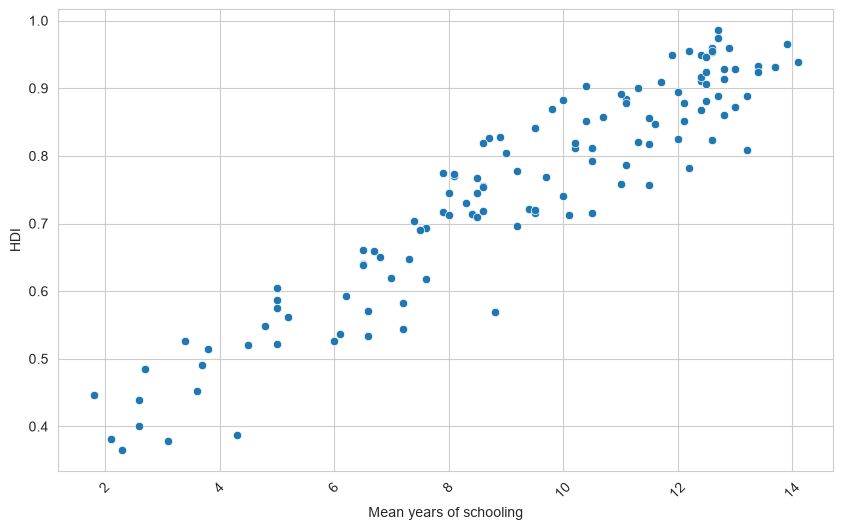

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Mean years of schooling",
    y="HDI",
    data=Development   
)

plt.xticks(rotation=45)
plt.show()

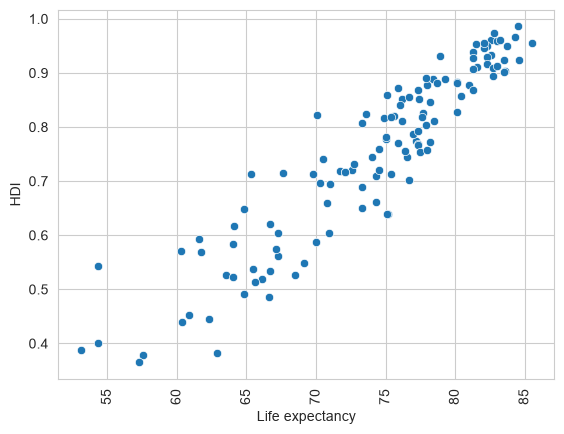

In [20]:
g=sns.scatterplot(x="Life expectancy", y="HDI", data=Development)
plt.xticks(rotation=90)
plt.show()

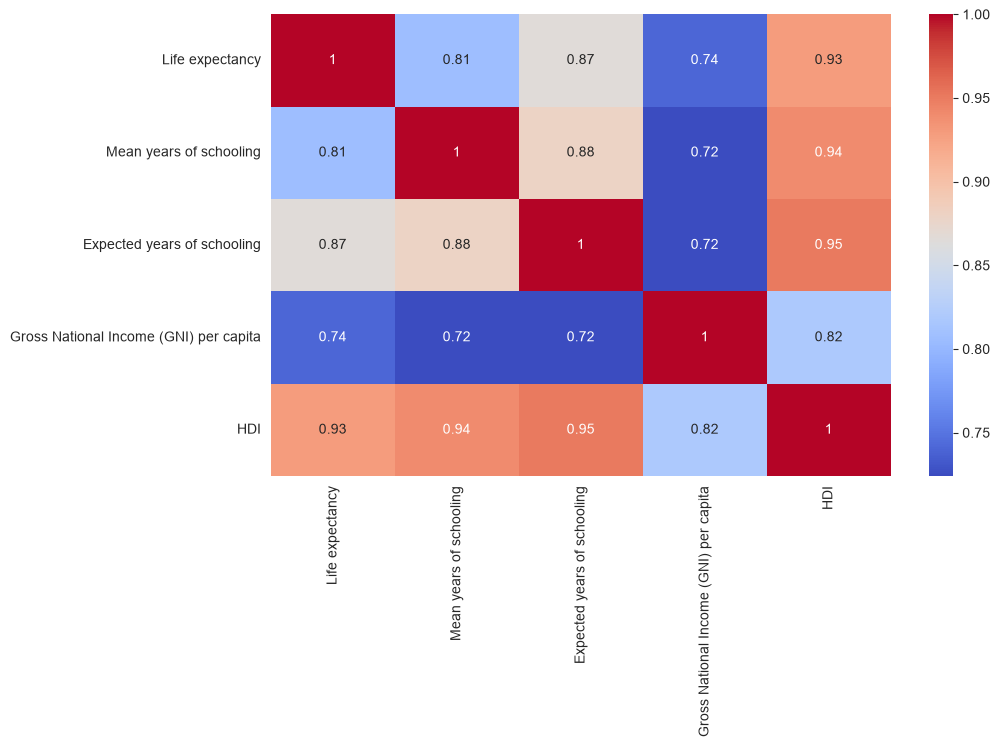

In [21]:

heat = Development.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(heat.corr(), annot=True, cmap='coolwarm')
plt.show()




In [22]:
X = Development.iloc[:, [0, 1, 2, 3, 4]]
X = pd.DataFrame(X)
y = Development.iloc[:, 5].values
y=pd.DataFrame(y)

In [23]:
X.isnull().sum()

Country                                   0
Life expectancy                           0
Mean years of schooling                   0
Expected years of schooling               0
Gross National Income (GNI) per capita    0
dtype: int64

In [24]:
new_data = pd.DataFrame([[72.0, 5.2, 14.4, 3341.0]],
                        columns=[
                            "Life expectancy",
                            "Mean years of schooling",
                            "Expected years of schooling",
                            "Gross National Income (GNI) per capita"
                        ])

y_pred = reg.predict(new_data)
print(y_pred)

[[0.65480607]]


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [26]:
y_test

,0
18,0.924
42,0.825
36,0.847
76,0.388
53,0.718
90,0.731
56,0.714
122,0.841
121,0.575
4,0.955


In [27]:
reg = LinearRegression()
reg.fit(X_train.iloc[:, 1:], y_train)
y_pred = reg.predict(X_test.iloc[:, 1:])
print(y_pred)

[[0.92706366]
 [0.8164352 ]
 [0.83719021]
 [0.41753682]
 [0.70174921]
 [0.70820116]
 [0.71396133]
 [0.81201576]
 [0.55967708]
 [0.96308285]
 [0.88938343]
 [0.57731607]
 [0.75939529]]


In [28]:
pickle.dump(reg, open('../Flask/HDI.pkl', 'wb'))